# Learning on Graphs - Homework 1


The loading of Karate Club, matched Erdos-Renyi controls, Cora, the oversmoothing graph, and the bonus barbell graphs is provided for you.

In [4]:
import os
import time
import random
import copy
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv


def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


In [5]:
# Provided graph/data loading.
G_karate = nx.karate_club_graph()
karate_club_labels = nx.get_node_attributes(G_karate, 'club')
karate_label_to_id = {'Mr. Hi': 0, 'Officer': 1}
karate_y = np.array([karate_label_to_id[karate_club_labels[i]]
                     for i in sorted(G_karate.nodes())])

n_karate = G_karate.number_of_nodes()
m_karate = G_karate.number_of_edges()
p_match = 2 * m_karate / (n_karate * (n_karate - 1))
er_graphs = [nx.erdos_renyi_graph(n_karate, p_match, seed=s) for s in [1, 2, 3]]

# Provided ER graph for the oversmoothing visualization in Part D.
def make_connected_er_graph(n=120, p=0.06, seed=7):
    for offset in range(1000):
        G = nx.erdos_renyi_graph(n, p, seed=seed + offset)
        if nx.is_connected(G):
            return G, seed + offset
    raise RuntimeError('Could not sample a connected ER graph')

G_over, G_over_seed = make_connected_er_graph(n=120, p=0.06, seed=7)
rng_over = np.random.default_rng(0)
over_signal0 = rng_over.normal(size=G_over.number_of_nodes())
over_signal0 = over_signal0 / np.max(np.abs(over_signal0))

# Provided graphs for the bonus.
G_barbell = nx.barbell_graph(8, 4)
G_shortcut = G_barbell.copy()
G_shortcut.add_edge(0, max(G_shortcut.nodes()))

# Cora citation network for Parts C and D.
dataset = Planetoid(root='data/Planetoid', name='Cora')
data = dataset[0].to(device)

print('Karate:', G_karate.number_of_nodes(), 'nodes,', G_karate.number_of_edges(), 'edges')
print('Karate labels in karate_y:', dict(zip(*np.unique(karate_y, return_counts=True))))
print('Matched ER p:', p_match)
print('Oversmoothing ER graph:', G_over.number_of_nodes(), 'nodes,', G_over.number_of_edges(), 'edges, seed', G_over_seed)
print(dataset)
print(data)
print('num_features:', dataset.num_features, 'num_classes:', dataset.num_classes)


Processing...
c:\Users\tomyl\.conda\envs\LoG\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\tomyl\.conda\envs\LoG\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\tomyl\.conda\envs\LoG\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\tomyl\.conda\envs\LoG\Lib\site-packages\t

Karate: 34 nodes, 78 edges
Karate labels in karate_y: {np.int64(0): np.int64(17), np.int64(1): np.int64(17)}
Matched ER p: 0.13903743315508021
Oversmoothing ER graph: 120 nodes, 430 edges, seed 7
Cora()
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
num_features: 1433 num_classes: 7


Done!


## Implementation note

The notebook loads the graphs and datasets for you, but it does **not** implement the graph-operator utilities. You should implement graph statistics, adjacency/Laplacian construction, normalized GCN matrices, Dirichlet energy, and pairwise-distance diagnostics yourself in the cells below. In particular, please note that you are expected to implement the operators yourselves, rather than using functions from pytorch-geometric or other libraries.

In [6]:
# TODO: implement these helper functions. Do not import them from another file.
# Keep the function names fixed so later cells are easy to write and grade.

def graph_stats(G, name='graph'):
    """Return graph statistics: nodes, edges, average degree, density, components, min degree, max degree."""
    nodes = G.number_of_nodes()
    edges = G.number_of_edges()
    degrees = list(d for n, d in G.degree())
    avg_deg = sum(degrees) / G.number_of_nodes()
    density = 2 * edges / (nodes * (nodes - 1))
    components = list(nx.connected_components(G))
    max_deg = max(degrees)
    min_deg = min(degrees)

    return nodes, edges, avg_deg, density, components, min_deg, max_deg


def adjacency_matrix_np(G):
    """Return the dense adjacency matrix using sorted node order."""
    return nx.to_numpy_array(G, nodelist=sorted(G.nodes()))


def laplacian_np(A):
    """Return L = D - A."""
    d = A.sum(axis=1)
    return np.diag(d) - A


def normalized_adjacency_np(A, add_self_loops=True):
    """Return D_hat^{-1/2} A_hat D_hat^{-1/2}, with A_hat = A + I when add_self_loops=True."""
    A_hat = A + np.eye(A.shape[0]) if add_self_loops else A
    d_hat = A_hat.sum(axis=1)

    d_inv_sqrt = 1.0 / np.sqrt(d_hat)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    return D_inv_sqrt @ A_hat @ D_inv_sqrt


def symmetric_gcn_matrix_nx(G):
    """Return S and L for a NetworkX graph, where S = D_hat^{-1/2} A_hat D_hat^{-1/2}."""
    A = adjacency_matrix_np(G)
    L = laplacian_np(A)
    S = normalized_adjacency_np(A, add_self_loops=True)
    return S, L


def symmetric_gcn_matrix_from_edge_index(edge_index, num_nodes, device):
    """Return S and L for a PyG graph represented by edge_index."""
    A = torch.zeros(num_nodes, num_nodes, device=device)
    A[edge_index[0], edge_index[1]] = 1.0
    # Symmetrize in case edge_index only stores one direction.
    A = ((A + A.T) > 0).float()

    d = A.sum(dim=1)
    L = torch.diag(d) - A

    A_hat = A + torch.eye(num_nodes, device=device)
    d_hat = A_hat.sum(dim=1)
    d_inv_sqrt = d_hat.pow(-0.5)
    D_inv_sqrt = torch.diag(d_inv_sqrt)
    S = D_inv_sqrt @ A_hat @ D_inv_sqrt
    return S, L


def dirichlet_energy(H, L):
    """Return Tr(H^T L H) as a Python float."""
    return torch.trace(H.T @ L @ H).item()


def mean_pairwise_distance(H, max_nodes=512):
    """Return the mean pairwise Euclidean distance between node embeddings.
    For large graphs, subsample at most max_nodes nodes.
    """
    n = H.shape[0]
    if n > max_nodes:
        idx = torch.randperm(n, device=H.device)[:max_nodes]
        H = H[idx]
    D = torch.cdist(H, H)  # (m, m) pairwise distances
    m = H.shape[0]
    # Average over the m*(m-1) ordered off-diagonal pairs (== unordered mean).
    return (D.sum() / (m * (m - 1))).item()


## Part B: NetworkX graph operators

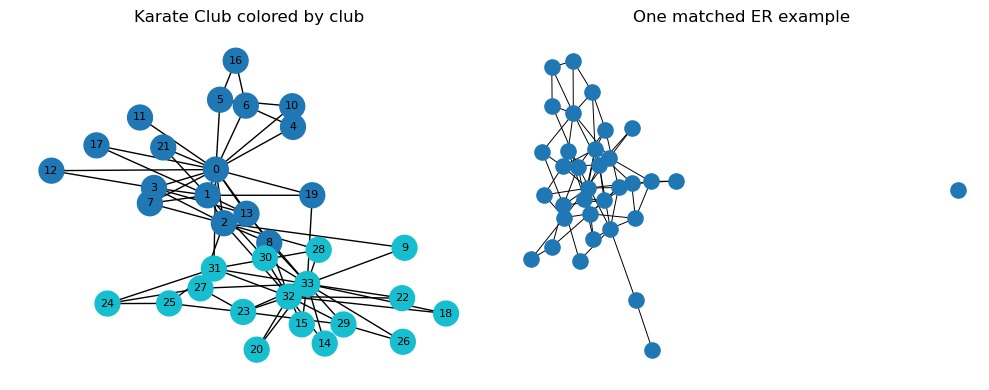

In [7]:
# Provided visual overview.
pos = nx.spring_layout(G_karate, seed=0)
node_colors = karate_y
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
nx.draw_networkx(G_karate, pos=pos, node_color=node_colors, cmap='tab10',
                 with_labels=True, node_size=320, font_size=8, ax=axes[0])
axes[0].set_title('Karate Club colored by club')
axes[0].axis('off')
nx.draw_networkx(er_graphs[0], pos=nx.spring_layout(er_graphs[0], seed=1),
                 with_labels=False, node_size=120, width=0.7, ax=axes[1])
axes[1].set_title('One matched ER example')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [8]:
# B1 TODO: report Karate statistics and club counts.
# Use karate_club_labels and karate_y from the loading cell.

nodes, edges, avg_deg, density, components, min_deg, max_deg = graph_stats(G_karate, 'karate')

print(f'nodes={nodes}, edges={edges}, avg_deg={avg_deg:.3f}, density={density:.4f}')
print(f'min_deg={min_deg}, max_deg={max_deg}, #components={len(components)}')

print('From karate_club_labels:', Counter(karate_club_labels.values()))
print('From karate_y         :', dict(zip(*np.unique(karate_y, return_counts=True))))

nodes=34, edges=78, avg_deg=4.588, density=0.1390
min_deg=1, max_deg=17, #components=1
From karate_club_labels: Counter({'Mr. Hi': 17, 'Officer': 17})
From karate_y         : {np.int64(0): np.int64(17), np.int64(1): np.int64(17)}


,graph,n,m,avg_deg,density,min_deg,max_deg,#comp
0,Karate,34,78,4.588,0.1390,1,17,1
1,ER_1,34,75,4.412,0.1337,0,9,2
2,ER_2,34,79,4.647,0.1408,0,9,2
3,ER_3,34,71,4.176,0.1266,1,10,1


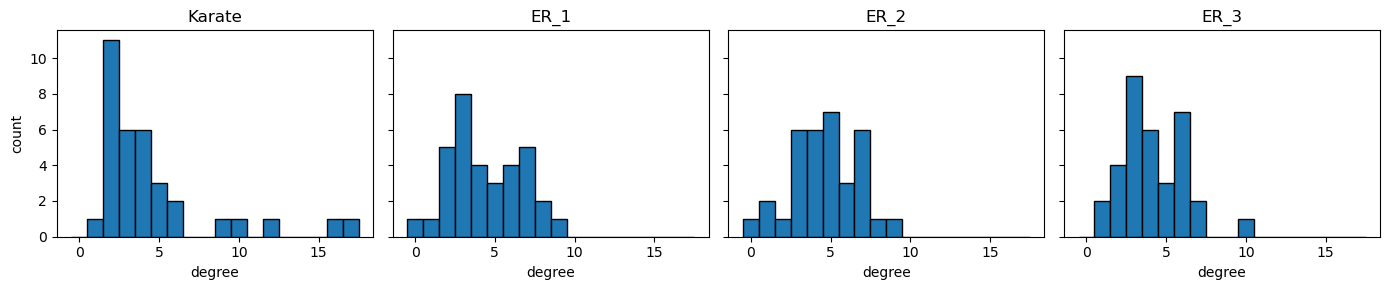

In [9]:
# B2 TODO: compare Karate with all three ER graphs and plot the degree histograms.

all_graphs = [('Karate', G_karate)] + [(f'ER_{i+1}', G) for i, G in enumerate(er_graphs)]

# 1) Stats table.
rows = []
for name, G in all_graphs:
    nodes, edges, avg_deg, density, components, min_deg, max_deg = graph_stats(G)
    rows.append({
        'graph': name,
        'n': nodes,
        'm': edges,
        'avg_deg': round(avg_deg, 3),
        'density': round(density, 4),
        'min_deg': min_deg,
        'max_deg': max_deg,
        '#comp': len(components),
    })
display(pd.DataFrame(rows))

# 2) Degree histograms with a shared integer-bin x-axis so shapes are comparable.
max_d = max(max(d for _, d in G.degree()) for _, G in all_graphs)
bins = np.arange(0, max_d + 2) - 0.5

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, (name, G) in zip(axes, all_graphs):
    degs = [d for _, d in G.degree()]
    ax.hist(degs, bins=bins, edgecolor='black')
    ax.set_title(name)
    ax.set_xlabel('degree')
axes[0].set_ylabel('count')
plt.tight_layout()
plt.show()

# Observation:
# All four graphs share n=34 and density ~0.139 by construction, so the average degrees match.
# Karate, however, has a heavy right tail (max_deg=17 -- the instructor and the president act
# as hubs), while the matched ER graphs have roughly binomial, symmetric degree distributions
# with much smaller max degrees. Matching (n, p) is not enough to reproduce real social structure.


### B2 — Discussion

**1. Are the ER graphs always connected?**
No, connectivity is probabilistic. In our run, ER_1 and ER_2 have 2 components while ER_3 is connected, even though all three use the same $(n, p)$

**2. How different are the degree distributions?**
Same mean (~4.59) by construction, but different shape:
- **Karate**: heavy right tail with hubs at degree 17 (Mr. Hi) and 16 (Officer), min = 1.
- **ER**: roughly binomial / symmetric around the mean, max degree only ≈ 9–10, no hubs.

Matching $(n, p)$ matches the first moment but not the structure — real social networks have organized hubs that pure randomness does not reproduce.

**3. Fixed Karate vs. random ER — why both?**
- Karate is identical on every run, so results are reproducible, and it carries real labeled community structure.
- ER is a distribution, varying the seed (or $n$, $p$) gives controlled variation: multiple seeds quantify random fluctuation. Any gap between Karate and the density-matched ER samples is then attributable to structure beyond density.


In [10]:
# B3 TODO: build A, D, L, and A_norm for Karate and report shape/nnz/density.

A = adjacency_matrix_np(G_karate)
D = np.diag(A.sum(axis=1))
L = laplacian_np(A)
A_norm = normalized_adjacency_np(A, add_self_loops=True)

print(f'{"matrix":<8} {"shape":<12} {"nnz":>6} {"density":>10}')
for name, M in [('A', A), ('D', D), ('L', L), ('A_norm', A_norm)]:
    nnz = int(np.count_nonzero(M))
    density = nnz / M.size
    print(f'{name:<8} {str(M.shape):<12} {nnz:>6d} {density:>10.4f}')

# Sanity checks.
assert np.allclose(A, A.T), 'A should be symmetric'
assert np.allclose(L, L.T), 'L should be symmetric'
assert np.allclose(A_norm, A_norm.T), 'A_norm should be symmetric'
assert np.allclose(L.sum(axis=1), 0), 'L rows should sum to 0'
print('symmetry and L row-sum checks passed.')


matrix   shape           nnz    density
A        (34, 34)        156     0.1349
D        (34, 34)         34     0.0294
L        (34, 34)        190     0.1644
A_norm   (34, 34)        190     0.1644
symmetry and L row-sum checks passed.


### Why dense adjacency matrices are not suitable for large sparse graphs

In sparse graphs the density is much lower than 1. Therefore using dense storage is wasteful in memory (almost every entry is zero), and wasteful in compute. Since $D$, $L$, $\tilde A$ depends on the adjacency matrix, this dense overhead builds up.


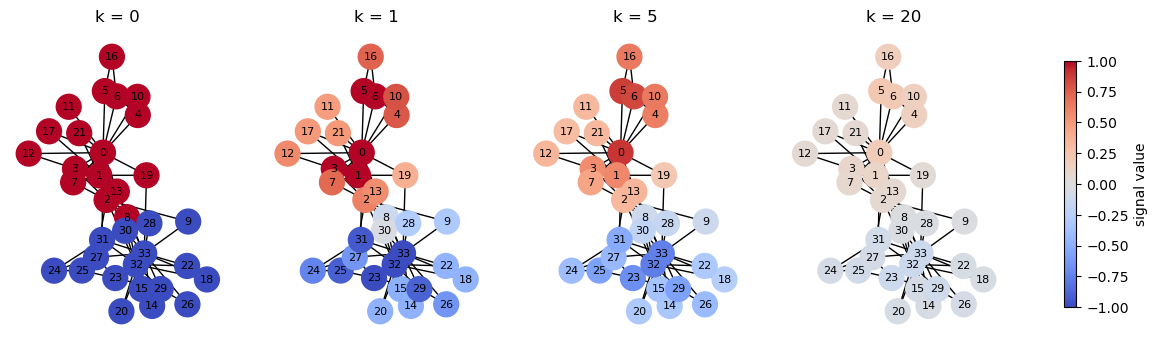

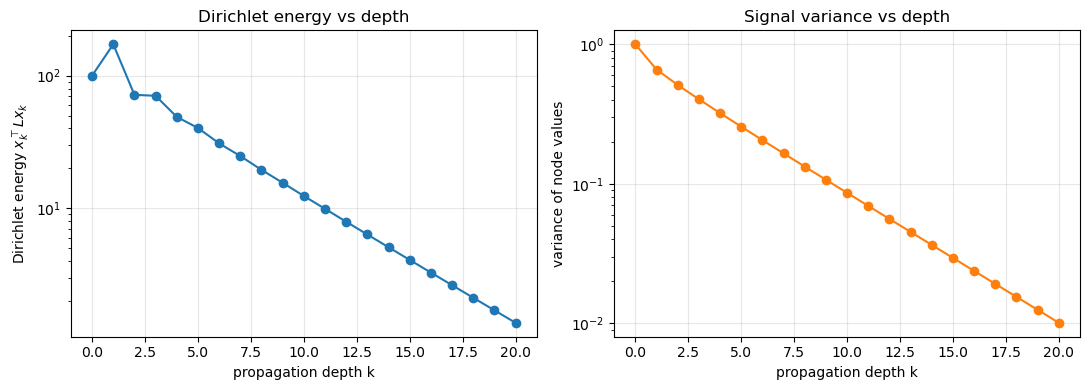

In [11]:
# B4 TODO:
# Use karate_y from the loading cell.
# Define signal0 = 1 - 2 * karate_y.
# Smooth it with A_norm for k = 0..20.
# Plot:
#   (1) signal on the graph for k = 0, 1, 5, 20, same color range
#   (2) Dirichlet energy x(k)^T L x(k) as a function of k
#   (3) variance of node values as a function of k

# Explicit column-vector convention: every x_k has shape (n, 1).
signal0 = (1 - 2 * karate_y).astype(float).reshape(-1, 1)  # (34, 1)

K = 20
signals = [signal0.copy()]
for _ in range(K):
    signals.append(A_norm @ signals[-1])  # (34, 34) @ (34, 1) -> (34, 1)

# (n_nodes, K+1)
signals_mat = np.hstack(signals)

energy = np.array([(x_k.T @ L @ x_k).item() for x_k in signals])

# Variance of node values at each k: collapses each column into a scalar
variance = signals_mat.var(axis=0)

snapshot_ks = [0, 1, 5, 20]
pos = nx.spring_layout(G_karate, seed=0)
fig, axes = plt.subplots(1, len(snapshot_ks), figsize=(4 * len(snapshot_ks), 4))
for ax, k in zip(axes, snapshot_ks):
    # networkx wants a 1-D array of node colors -> flatten the (n,1) column.
    nx.draw_networkx(
        G_karate, pos=pos,
        node_color=signals[k].flatten(), cmap='coolwarm', vmin=-1, vmax=1,
        with_labels=True, node_size=320, font_size=8, ax=ax,
    )
    ax.set_title(f'k = {k}')
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-1, vmax=1))
sm.set_array([])
fig.colorbar(sm, ax=axes, shrink=0.8, label='signal value')
plt.show()

# ----- (2) and (3) Dirichlet energy and variance vs depth.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(range(K + 1), energy, marker='o')
axes[0].set_yscale('log')
axes[0].set_xlabel('propagation depth k')
axes[0].set_ylabel(r'Dirichlet energy $x_k^\top L x_k$')
axes[0].set_title('Dirichlet energy vs depth')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(K + 1), variance, marker='o', color='C1')
axes[1].set_yscale('log')
axes[1].set_xlabel('propagation depth k')
axes[1].set_ylabel('variance of node values')
axes[1].set_title('Signal variance vs depth')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Both Dirichlet energy and variance decay monotonically: every eigenvalue of $\tilde A$ except $\lambda_1 = 1$ has $|\lambda_i| < 1$, so non-smooth components shrink geometrically and only the smoothest mode survives, i.e. the **oversmoothing** phenomenon.


## Part C: Semi-supervised node classification with GCN on Cora

In [12]:
# C1 TODO: report Cora dataset statistics and explain why this setup is transductive.

n_nodes = data.num_nodes
n_edges_directed = data.num_edges                # PyG stores both directions
n_edges_undirected = n_edges_directed // 2
n_features = dataset.num_features
n_classes = dataset.num_classes
avg_deg = n_edges_directed / n_nodes             # = (2 * undirected edges) / n

n_train = int(data.train_mask.sum().item())
n_val   = int(data.val_mask.sum().item())
n_test  = int(data.test_mask.sum().item())

print(f'Cora citation network')
print(f'  nodes              : {n_nodes}')
print(f'  edges (undirected) : {n_edges_undirected}')
print(f'  features per node  : {n_features}')
print(f'  classes            : {n_classes}')
print(f'  avg degree         : {avg_deg:.3f}')
print(f'  train / val / test : {n_train} / {n_val} / {n_test}  '
      f'({n_train/n_nodes:.1%} / {n_val/n_nodes:.1%} / {n_test/n_nodes:.1%})')

# Per-class label counts on the training set.
train_labels = data.y[data.train_mask].cpu().numpy()
print('  train labels/class :', dict(zip(*np.unique(train_labels, return_counts=True))))

Cora citation network
  nodes              : 2708
  edges (undirected) : 5278
  features per node  : 1433
  classes            : 7
  avg degree         : 3.898
  train / val / test : 140 / 500 / 1000  (5.2% / 18.5% / 36.9%)
  train labels/class : {np.int64(0): np.int64(20), np.int64(1): np.int64(20), np.int64(2): np.int64(20), np.int64(3): np.int64(20), np.int64(4): np.int64(20), np.int64(5): np.int64(20), np.int64(6): np.int64(20)}


### Why this is a transductive node-classification setup

A single fixed graph with all 2,708 nodes, all edges, and all features is shared across train/val/test; only the label masks differ. Message passing already sees unlabeled nodes during training, and predictions are made for every node of the same graph: the defining property of transductive node classification.



MLP — 92,231 trainable params
epoch   1  loss 1.9500  train_acc 0.6143  val_acc 0.1360
epoch  50  loss 0.0167  train_acc 1.0000  val_acc 0.5680
epoch 100  loss 0.0119  train_acc 1.0000  val_acc 0.5620
epoch 150  loss 0.0067  train_acc 1.0000  val_acc 0.5700
epoch 200  loss 0.0098  train_acc 1.0000  val_acc 0.5360
epoch 250  loss 0.0093  train_acc 1.0000  val_acc 0.5460
epoch 300  loss 0.0069  train_acc 1.0000  val_acc 0.5700
epoch 350  loss 0.0080  train_acc 1.0000  val_acc 0.5440
epoch 400  loss 0.0109  train_acc 1.0000  val_acc 0.5360
epoch 450  loss 0.0109  train_acc 1.0000  val_acc 0.5440
epoch 500  loss 0.0081  train_acc 1.0000  val_acc 0.5620

GCN — 92,231 trainable params
epoch   1  loss 1.9337  train_acc 0.8143  val_acc 0.5000
epoch  50  loss 0.0082  train_acc 1.0000  val_acc 0.7760
epoch 100  loss 0.0138  train_acc 1.0000  val_acc 0.7620
epoch 150  loss 0.0087  train_acc 1.0000  val_acc 0.7720
epoch 200  loss 0.0114  train_acc 1.0000  val_acc 0.7560
epoch 250  loss 0.0090  tr

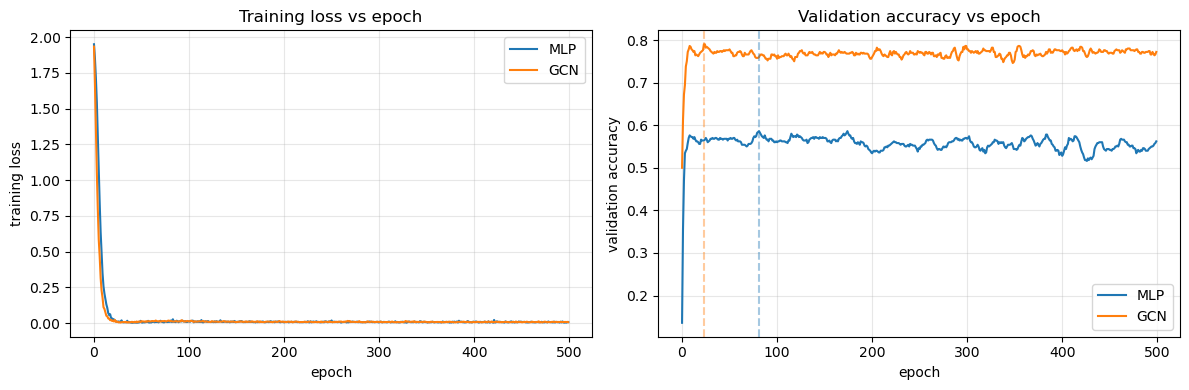

In [ ]:
# C2-C4: MLP vs two-layer GCN on Cora.
# Train both for exactly 500 epochs, select the checkpoint with best validation accuracy,
# then plot loss and val accuracy.

def count_parameters(model):
    """Number of trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def accuracy_from_logits(logits, y, mask):
    """Accuracy of argmax(logits) vs y, evaluated only on nodes selected by mask."""
    preds = logits[mask].argmax(dim=-1)
    correct = (preds == y[mask]).sum().item()
    return correct / int(mask.sum().item())


class MLP(nn.Module):
    """Two-layer MLP that ignores the graph structure."""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index=None):
        h = F.relu(self.lin1(x))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.lin2(h)


class GCN(nn.Module):
    """Two-layer GCN built from torch_geometric.nn.GCNConv."""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.conv2(h, edge_index)


def train_pyg_model(model, data, epochs=500, lr=0.01, weight_decay=5e-4, verbose=True):
    """Train a model on a PyG `data` object for `epochs` epochs.
    Tracks per-epoch loss and val accuracy, and keeps the best-val-accuracy checkpoint.
    Returns: history dict, best_state_dict, best_val_acc, best_epoch.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {'loss': [], 'val_acc': [], 'train_acc': []}
    best_val_acc = -1.0
    best_state = None
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(data.x, data.edge_index)
        loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(data.x, data.edge_index)
            train_acc = accuracy_from_logits(logits, data.y, data.train_mask)
            val_acc   = accuracy_from_logits(logits, data.y, data.val_mask)

        history['loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if verbose and (epoch == 1 or epoch % 50 == 0 or epoch == epochs):
            print(f'epoch {epoch:>3d}  loss {loss.item():.4f}  '
                  f'train_acc {train_acc:.4f}  val_acc {val_acc:.4f}')

    return history, best_state, best_val_acc, best_epoch


# train both models
set_seed(0)
mlp = MLP(dataset.num_features, 64, dataset.num_classes).to(device)
print(f'\nMLP — {count_parameters(mlp):,} trainable params')
mlp_hist, mlp_best_state, mlp_best_val, mlp_best_epoch = train_pyg_model(mlp, data, epochs=500)

set_seed(0)
gcn = GCN(dataset.num_features, 64, dataset.num_classes).to(device)
print(f'\nGCN — {count_parameters(gcn):,} trainable params')
gcn_hist, gcn_best_state, gcn_best_val, gcn_best_epoch = train_pyg_model(gcn, data, epochs=500)

# restore best val checkpoint and report test accuracy
mlp.load_state_dict(mlp_best_state)
gcn.load_state_dict(gcn_best_state)

mlp.eval()
gcn.eval()
with torch.no_grad():
    mlp_test_acc = accuracy_from_logits(mlp(data.x, data.edge_index), data.y, data.test_mask)
    gcn_test_acc = accuracy_from_logits(gcn(data.x, data.edge_index), data.y, data.test_mask)

print('\n=== Best-val checkpoint summary ===')
print(f'MLP: best val acc = {mlp_best_val:.4f} (epoch {mlp_best_epoch}),  test acc = {mlp_test_acc:.4f}')
print(f'GCN: best val acc = {gcn_best_val:.4f} (epoch {gcn_best_epoch}),  test acc = {gcn_test_acc:.4f}')

# Plots: training loss and validation accuracy over 500 epochs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mlp_hist['loss'], label='MLP')
axes[0].plot(gcn_hist['loss'], label='GCN')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('training loss')
axes[0].set_title('Training loss vs epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(mlp_hist['val_acc'], label='MLP')
axes[1].plot(gcn_hist['val_acc'], label='GCN')
axes[1].axvline(mlp_best_epoch - 1, color='C0', linestyle='--', alpha=0.4)
axes[1].axvline(gcn_best_epoch - 1, color='C1', linestyle='--', alpha=0.4)
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('validation accuracy')
axes[1].set_title('Validation accuracy vs epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### C2–C4 — Discussion

The MLP treats each paper as an independent bag-of-words vector and ignores the citation graph, while the two `GCNConv` layers mix each node's features with its 2-hop neighborhood. This exploits Cora's homophily (cited papers tend to share a label) and lifts test accuracy from **57.1%** to **79.6%**, a 22-point gap that comes entirely from the graph. Both models have the same parameter count (92,231), so structural information is the dominant factor here, not model capacity. Both models also overfit: training accuracy hits 1.0 within ~50 epochs, the MLP's best-val checkpoint is at epoch 82 and the GCN's at epoch 24, and validation accuracy stagnates beyond those points. For the GCN the best-val (0.790) and test (0.796) accuracies agree within noise, so the selected checkpoint generalizes well.


## Part D: Depth and oversmoothing with fixed GCN propagation

In this part there are **no trainable weights**. Use the fixed GCN propagation matrix
\[
S = \widehat D^{-1/2}\widehat A\widehat D^{-1/2}, \quad \widehat A=A+I.
\]
Starting from Cora node features, compute \(H^{(k+1)} = S H^{(k)}\). This isolates the smoothing effect of repeated GCN propagation.


   k     Dirichlet energy     mean pairwise dist
   0           1.6096e+05             5.8109e+00
   1           3.5364e+04             3.1777e+00
   2           1.4514e+04             2.5217e+00
   4           1.1778e+04             2.0414e+00
   8           1.0237e+04             1.6033e+00
  16           9.1144e+03             1.3000e+00
  32           8.3409e+03             1.0352e+00
  64           7.8904e+03             8.0728e-01


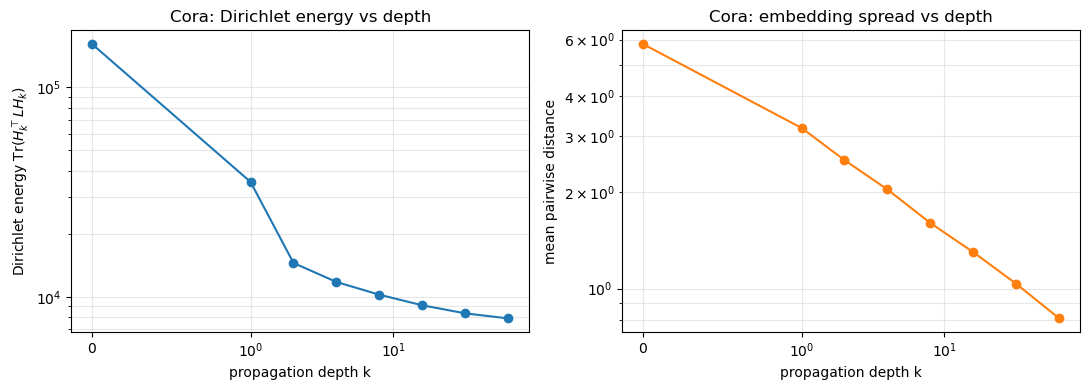

In [14]:
# D1 - record propogated signal at specific depths
set_seed(0)

S_cora, L_cora = symmetric_gcn_matrix_from_edge_index(
    data.edge_index, data.num_nodes, device
)

depths = [0, 1, 2, 4, 8, 16, 32, 64]
max_depth = max(depths)
record_set = set(depths)

H = data.x.float()  # (2708, 1433)

# depth -> (energy, mean pairwise node-feature distance)
records = {0: (dirichlet_energy(H, L_cora), mean_pairwise_distance(H))} 

for k in range(1, max_depth + 1): #iterating 1, ..., 64
    H = S_cora @ H
    if k in record_set: # logging specific depths from depths
        records[k] = (dirichlet_energy(H, L_cora), mean_pairwise_distance(H))


# D2 - plot logged depths  recorded quantites
print(f'{"k":>4} {"Dirichlet energy":>20} {"mean pairwise dist":>22}')
for k in depths:
    e, m = records[k]
    print(f'{k:>4d} {e:>20.4e} {m:>22.4e}')

energies = [records[k][0] for k in depths]
mpds     = [records[k][1] for k in depths]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(depths, energies, marker='o')
axes[0].set_xscale('symlog', linthresh=1)
axes[0].set_yscale('log')
axes[0].set_xlabel('propagation depth k')
axes[0].set_ylabel(r'Dirichlet energy $\operatorname{Tr}(H_k^\top L H_k)$')
axes[0].set_title('Cora: Dirichlet energy vs depth')
axes[0].grid(True, alpha=0.3, which='both')

axes[1].plot(depths, mpds, marker='o', color='C1')
axes[1].set_xscale('symlog', linthresh=1)
axes[1].set_yscale('log')
axes[1].set_xlabel('propagation depth k')
axes[1].set_ylabel('mean pairwise distance')
axes[1].set_title('Cora: embedding spread vs depth')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


   k     Dirichlet energy       variance     mean pairwise dist
   0           1.5412e+02     1.6869e-01             4.7191e-01
   1           1.0542e+01     1.3737e-02             1.3096e-01
   2           1.5142e+00     2.7011e-03             5.9093e-02
   4           1.0330e-01     2.4317e-04             1.7505e-02
   8           7.8136e-03     1.2734e-05             4.0097e-03
  16           6.4629e-03     8.5276e-06             3.3198e-03
  32           6.4595e-03     8.5253e-06             3.3131e-03
  64           6.4595e-03     8.5253e-06             3.3130e-03


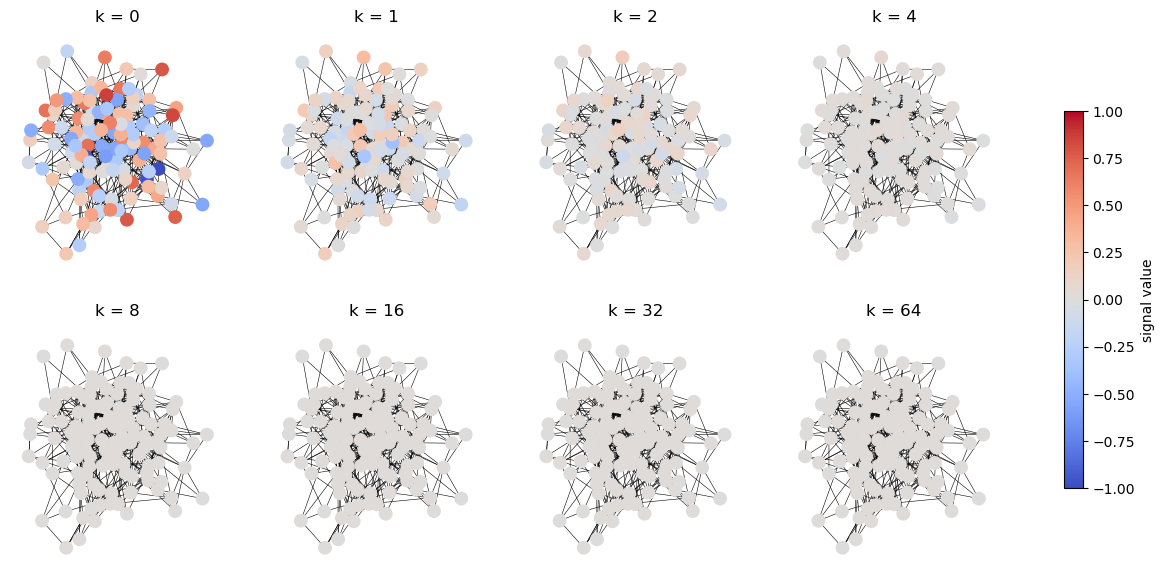

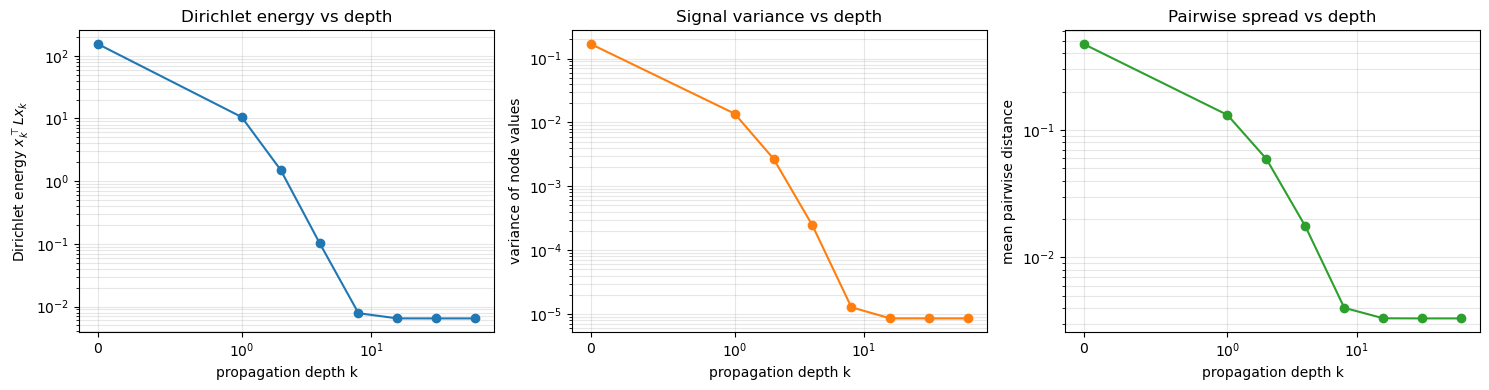

In [15]:
# D3: oversmoothing visualization on the provided ER graph G_over with over_signal0.
# Propagate with the symmetric GCN matrix for depths [0,1,2,4,8,16,32,64].
# Plot Dirichlet energy, variance, mean pairwise distance, and snapshots
# with the same color range vmin=-1, vmax=1.

# logging signal at specific depths:
set_seed(0)

S_over, L_over = symmetric_gcn_matrix_nx(G_over)

x0 = over_signal0.astype(float).reshape(-1, 1)  # (120, 1)

depths = [0, 1, 2, 4, 8, 16, 32, 64]
max_depth = max(depths)
record_set = set(depths)


signals = {0: x0.copy()}
x = x0.copy()
for k in range(1, max_depth + 1):
    x = S_over @ x
    if k in record_set:
        signals[k] = x.copy()

# ----- Diagnostics: Dirichlet energy, variance, mean pairwise distance
energies = []
variances = []
mpds = []
for k in depths:
    xk = signals[k]                              # (120, 1) numpy
    energies.append((xk.T @ L_over @ xk).item())
    variances.append(float(xk.var()))
    # Reuse the torch helper: (120, 1) -> torch tensor on CPU (graph is tiny).
    mpds.append(mean_pairwise_distance(torch.from_numpy(xk)))

print(f'{"k":>4} {"Dirichlet energy":>20} {"variance":>14} {"mean pairwise dist":>22}')
for k, e, v, m in zip(depths, energies, variances, mpds):
    print(f'{k:>4d} {e:>20.4e} {v:>14.4e} {m:>22.4e}')

# ----- Snapshot grid: all 8 depths with shared color range.
pos_over = nx.spring_layout(G_over, seed=0)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, k in zip(axes.flat, depths):
    nx.draw_networkx(
        G_over, pos=pos_over,
        node_color=signals[k].flatten(), cmap='coolwarm', vmin=-1, vmax=1,
        with_labels=False, node_size=80, width=0.4, ax=ax,
    )
    ax.set_title(f'k = {k}')
    ax.axis('off')
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-1, vmax=1))
sm.set_array([])
fig.colorbar(sm, ax=axes, shrink=0.7, label='signal value')
plt.show()

# ----- Three diagnostic curves vs depth.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(depths, energies, marker='o')
axes[0].set_xscale('symlog', linthresh=1)
axes[0].set_yscale('log')
axes[0].set_xlabel('propagation depth k')
axes[0].set_ylabel(r'Dirichlet energy $x_k^\top L x_k$')
axes[0].set_title('Dirichlet energy vs depth')
axes[0].grid(True, alpha=0.3, which='both')

axes[1].plot(depths, variances, marker='o', color='C1')
axes[1].set_xscale('symlog', linthresh=1)
axes[1].set_yscale('log')
axes[1].set_xlabel('propagation depth k')
axes[1].set_ylabel('variance of node values')
axes[1].set_title('Signal variance vs depth')
axes[1].grid(True, alpha=0.3, which='both')

axes[2].plot(depths, mpds, marker='o', color='C2')
axes[2].set_xscale('symlog', linthresh=1)
axes[2].set_yscale('log')
axes[2].set_xlabel('propagation depth k')
axes[2].set_ylabel('mean pairwise distance')
axes[2].set_title('Pairwise spread vs depth')
axes[2].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


### D4 — Range vs. discriminability

Each application of $S$ mixes a node with its 1-hop neighbors, so after $k$ steps every node has aggregated information from its $k$-hop neighborhood: the communication range grows linearly with depth. However, $S$ has eigenvalues in $(-1, 1]$, so writing $H^{(k)} = \sum_i \lambda_i^k c_i u_i$, every non-leading coefficient decays as $|\lambda_i|^k \to 0$ and only the smooth $u_1$ mode survives. This matches the empirical curves on Cora and $G_\text{over}$: Dirichlet energy and mean pairwise distance both decay roughly geometrically, and by $k=64$ the embeddings are nearly indistinguishable.


## Part E: 1-WL and expressivity toy study

Path5 and Star5 are a same-size warmup pair with 5 nodes each. The real failure example is C6 versus 2K3, which are both 6-node graphs. Do not compare 5-node graphs to 6-node graphs as an isomorphism test.


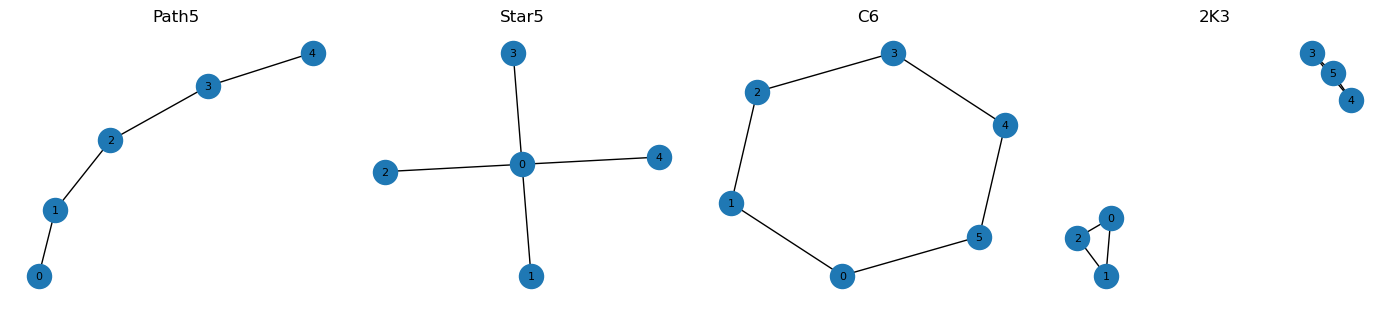

In [16]:
# Provided toy graph visualization.
graphs = {
    'Path5': nx.path_graph(5),
    'Star5': nx.star_graph(4),
    'C6': nx.cycle_graph(6),
    '2K3': nx.disjoint_union(nx.complete_graph(3), nx.complete_graph(3)),
}
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, (name, G) in zip(axes, graphs.items()):
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=0), with_labels=True,
                     node_size=300, font_size=8, ax=ax)
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

Path5 color multisets per round:
  round 0: {0: 5}
  round 1: {0: 2, 1: 3}
  round 2: {0: 2, 1: 2, 2: 1}
  round 3: {0: 2, 1: 2, 2: 1}

Star5 color multisets per round:
  round 0: {0: 5}
  round 1: {1: 1, 0: 4}
  round 2: {1: 1, 0: 4}
  round 3: {1: 1, 0: 4}

C6 color multisets per round:
  round 0: {0: 6}
  round 1: {0: 6}
  round 2: {0: 6}
  round 3: {0: 6}

2K3 color multisets per round:
  round 0: {0: 6}
  round 1: {0: 6}
  round 2: {0: 6}
  round 3: {0: 6}

1-WL distinguishes Path5 from Star5 : True
1-WL distinguishes C6 from 2K3      : False


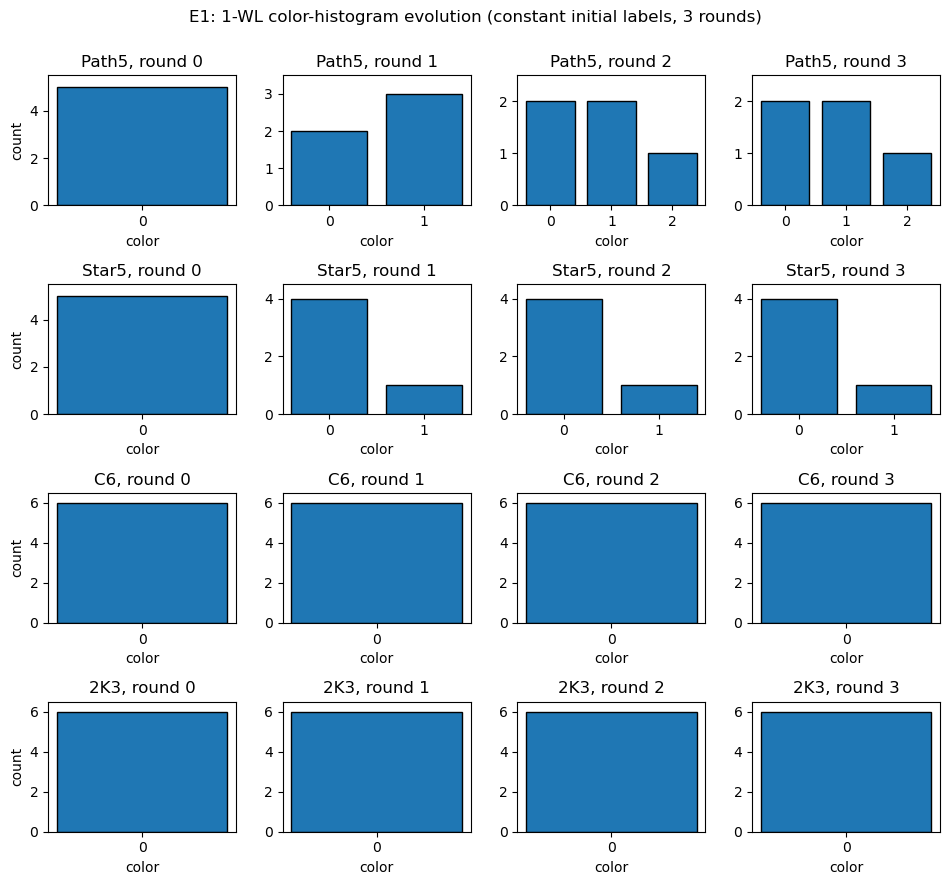

In [17]:
# E1: 1-WL color refinement.
# 1-WL: at each round, every node's new color is a deterministic function of
# (its current color, sorted multiset of its neighbors' current colors).
# Two graphs are *possibly* isomorphic only if their color histograms match at every round;
# if the histograms differ at any round, the graphs are provably non-isomorphic.

def wl_refine(G, n_iter=4, init_labels=None):
    """Run 1-WL color refinement.
    Returns a list `history` of length n_iter+1 where history[t] is a dict {node: color_int}.
    Colors at each round are compressed to small ints 0..K-1 in a graph-internal way
    (NOT shared across graphs). To compare two graphs' histograms across rounds,
    compare the multiset Counter(history[t].values()).
    """
    if init_labels is None:
        labels = {v: 0 for v in G.nodes()}
    else:
        labels = dict(init_labels)
    history = [dict(labels)]

    for _ in range(n_iter):
        # Signature for each node = (own color, sorted tuple of neighbor colors).
        sigs = {v: (labels[v], tuple(sorted(labels[u] for u in G.neighbors(v))))
                for v in G.nodes()}
        # Compress signatures to small ints, with a stable ordering for readability.
        unique_sigs = sorted(set(sigs.values()))
        sig_to_int = {s: i for i, s in enumerate(unique_sigs)}
        labels = {v: sig_to_int[sigs[v]] for v in G.nodes()}
        history.append(dict(labels))

    return history


def histogram_evolution(history):
    """Return list of Counters (color multiset) per round."""
    return [Counter(h.values()) for h in history]


def wl_histograms(G, n_iter=3, init_labels=None):
    """Spec-facing wrapper: returns the color histogram (Counter) per round."""
    return histogram_evolution(wl_refine(G, n_iter=n_iter, init_labels=init_labels))


def plot_histogram_evolution(name_to_history, suptitle):
    """Plot per-round color-multiset histograms for one or more graphs side by side."""
    n_graphs = len(name_to_history)
    n_rounds = len(next(iter(name_to_history.values())))
    fig, axes = plt.subplots(n_graphs, n_rounds, figsize=(2.4 * n_rounds, 2.2 * n_graphs),
                             squeeze=False)
    for i, (name, history) in enumerate(name_to_history.items()):
        hists = histogram_evolution(history)
        for t, (ax, c) in enumerate(zip(axes[i], hists)):
            colors = sorted(c.keys())
            counts = [c[k] for k in colors]
            ax.bar([str(k) for k in colors], counts, edgecolor='black')
            ax.set_title(f'{name}, round {t}')
            ax.set_ylim(0, max(max(counts), 1) + 0.5)
            if t == 0:
                ax.set_ylabel('count')
            ax.set_xlabel('color')
    fig.suptitle(suptitle, y=1.0)
    plt.tight_layout()
    plt.show()


# ----- Run 1-WL on all four required graphs.
n_iter = 3
histories = {name: wl_refine(G, n_iter=n_iter) for name, G in graphs.items()}

for name, hist in histories.items():
    print(f'{name} color multisets per round:')
    for t, c in enumerate(histogram_evolution(hist)):
        print(f'  round {t}: {dict(c)}')
    print()

# Sanity checks on the two pairs.
def same_histograms(h1, h2):
    e1, e2 = histogram_evolution(h1), histogram_evolution(h2)
    return all(a == b for a, b in zip(e1, e2))

print(f'1-WL distinguishes Path5 from Star5 : {not same_histograms(histories["Path5"], histories["Star5"])}')
print(f'1-WL distinguishes C6 from 2K3      : {not same_histograms(histories["C6"],    histories["2K3"])}')

plot_histogram_evolution(
    histories,
    'E1: 1-WL color-histogram evolution (constant initial labels, 3 rounds)',
)


C6  color multisets per round:
  round 0: {0: 6}
  round 1: {0: 6}
  round 2: {0: 6}
  round 3: {0: 6}
  round 4: {0: 6}
2K3 color multisets per round:
  round 0: {0: 6}
  round 1: {0: 6}
  round 2: {0: 6}
  round 3: {0: 6}
  round 4: {0: 6}

1-WL histograms identical at every round (i.e., 1-WL CANNOT distinguish): True


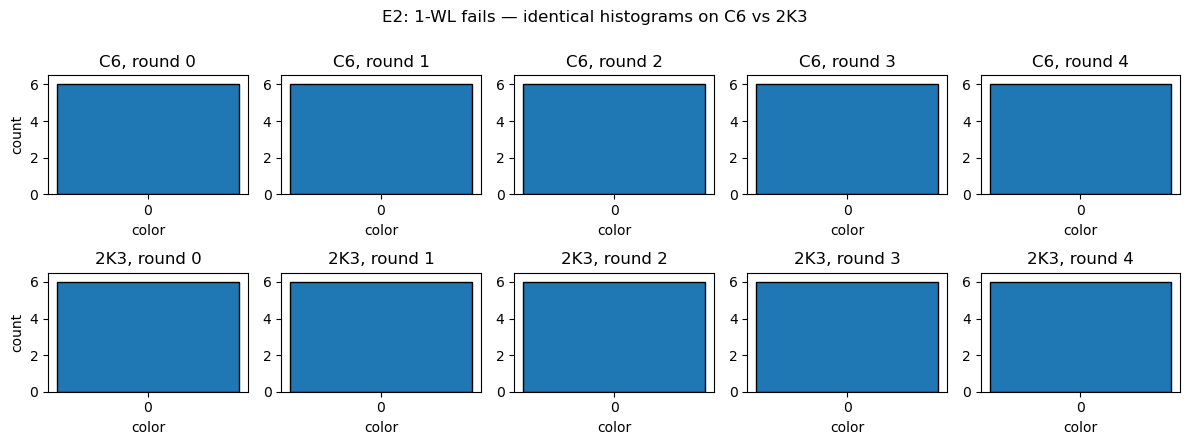

In [18]:
# E2: constant-label 1-WL fails on C6 vs 2K3.
# Both are 6-node, 2-regular graphs, so every node has the same local view at every round.

n_iter_fail = 4
hist_c6  = wl_refine(graphs['C6'],  n_iter=n_iter_fail)
hist_2k3 = wl_refine(graphs['2K3'], n_iter=n_iter_fail)

print('C6  color multisets per round:')
for t, c in enumerate(histogram_evolution(hist_c6)):
    print(f'  round {t}: {dict(c)}')
print('2K3 color multisets per round:')
for t, c in enumerate(histogram_evolution(hist_2k3)):
    print(f'  round {t}: {dict(c)}')

identical = all(
    histogram_evolution(hist_c6)[t] == histogram_evolution(hist_2k3)[t]
    for t in range(n_iter_fail + 1)
)
print(f'\n1-WL histograms identical at every round (i.e., 1-WL CANNOT distinguish): {identical}')

plot_histogram_evolution(
    {'C6': hist_c6, '2K3': hist_2k3},
    'E2: 1-WL fails — identical histograms on C6 vs 2K3',
)


### E2 — Why every node receives the same update at every iteration

$C_6$ and $2K_3$ both keep the histogram $\{0\!:\!6\}$ at every round, so 1-WL with constant initial labels cannot distinguish them. Both $C_6$ and $2K_3$ are 2-regular, so under constant initial labels every node has the same color as its two neighbors from round 1 onward. Every node therefore observes the same neighbor-color multiset and is updated to the same new color, leaving the histogram a single color of multiplicity 6 at every round. The same argument applies to any two $r$-regular graphs of the same size, so the failure is structural and independent of $n$.


RWSE on C6 (rows = nodes, columns = k = 1..6):
[[0.     0.5    0.     0.375  0.     0.3438]
 [0.     0.5    0.     0.375  0.     0.3438]
 [0.     0.5    0.     0.375  0.     0.3438]
 [0.     0.5    0.     0.375  0.     0.3438]
 [0.     0.5    0.     0.375  0.     0.3438]
 [0.     0.5    0.     0.375  0.     0.3438]]

RWSE on 2K3 (rows = nodes, columns = k = 1..6):
[[0.     0.5    0.25   0.375  0.3125 0.3438]
 [0.     0.5    0.25   0.375  0.3125 0.3438]
 [0.     0.5    0.25   0.375  0.3125 0.3438]
 [0.     0.5    0.25   0.375  0.3125 0.3438]
 [0.     0.5    0.25   0.375  0.3125 0.3438]
 [0.     0.5    0.25   0.375  0.3125 0.3438]]

RWSE distinguishes C6 from 2K3 (as a multiset of node features): True


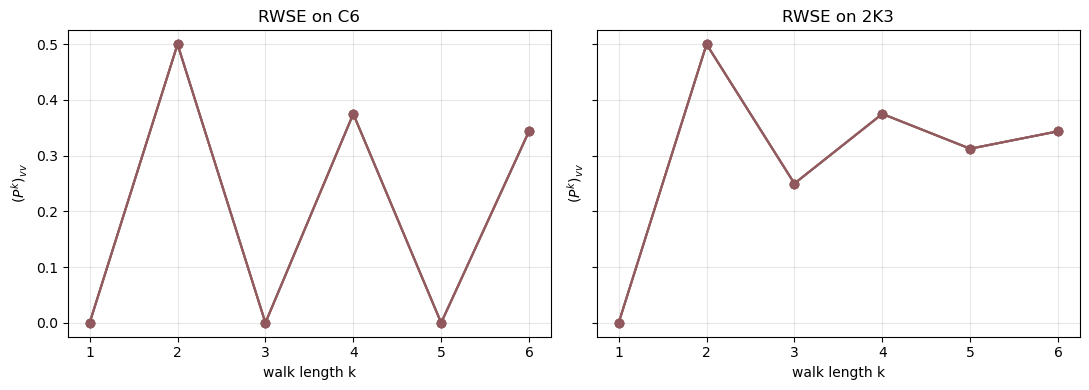

In [19]:
# E3: Random-Walk Structural Encoding (RWSE) on C6 vs 2K3.
# RWSE_k(v) = (P^k)_{vv} where P = D^{-1} A is the random walk transition matrix.
# This is the probability of returning to v after exactly k steps.
# It is a per-node structural feature that is permutation-equivariant
# (relabeling nodes permutes the feature vector accordingly).

def rwse(G, K=6):
    """Return an (n, K) array whose row v is [P^1_{vv}, P^2_{vv}, ..., P^K_{vv}]."""
    A = adjacency_matrix_np(G)
    d = A.sum(axis=1)
    P = A / d[:, None]                       # row-stochastic random walk matrix
    n = A.shape[0]
    feats = np.zeros((n, K))
    Pk = np.eye(n)
    for k in range(1, K + 1):
        Pk = Pk @ P
        feats[:, k - 1] = np.diag(Pk)        # P^k_vv is the diagonal of P^k
    return feats


K_rw = 6
rwse_c6  = rwse(graphs['C6'],  K=K_rw)
rwse_2k3 = rwse(graphs['2K3'], K=K_rw)

print('RWSE on C6 (rows = nodes, columns = k = 1..6):')
print(np.round(rwse_c6, 4))
print('\nRWSE on 2K3 (rows = nodes, columns = k = 1..6):')
print(np.round(rwse_2k3, 4))

# Compare graph-level RWSE multisets (sorted rows make us permutation-invariant).
c6_sorted  = np.array(sorted(map(tuple, np.round(rwse_c6,  6))))
k3_sorted  = np.array(sorted(map(tuple, np.round(rwse_2k3, 6))))
distinguish_rwse = not np.allclose(c6_sorted, k3_sorted)
print(f'\nRWSE distinguishes C6 from 2K3 (as a multiset of node features): {distinguish_rwse}')

# Visualize: plot per-node RWSE curve.
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name, feats in [(axes[0], 'C6', rwse_c6), (axes[1], '2K3', rwse_2k3)]:
    for v in range(feats.shape[0]):
        ax.plot(range(1, K_rw + 1), feats[v], marker='o', alpha=0.6, label=f'node {v}')
    ax.set_title(f'RWSE on {name}')
    ax.set_xlabel('walk length k')
    ax.set_ylabel(r'$(P^k)_{vv}$')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### E3 — Discussion

**1. Does RWSE distinguish C6 from 2K3?**
Yes. C6 is bipartite, so $(P^k)_{vv} = 0$ for all odd $k$, while in 2K3 the 3-cycle gives $(P^3)_{vv} = 1/4$ at every node. The column $k=3$ alone separates the two graphs because their RWSE feature multisets are different.

**2. Why is RWSE more principled than arbitrary node IDs?**
RWSE is a function of the graph itself: $\text{RWSE}_k(v) = (D^{-1}A)^k_{vv}$ is determined by structure (cycle counts, bipartiteness, ...) and is the same for isomorphic graphs. Node IDs are arbitrary labels — they distinguish anything trivially because they encode the labeling, not the structure, so a model using them is fitting the indexing rather than the graph.

**3. Permutation equivariance / invariance?**
RWSE is permutation-equivariant at the node level: relabeling nodes by a permutation $\pi$ permutes the RWSE feature vector by the same $\pi$, since $(P^{\pi})^k_{\pi(v)\pi(v)} = (P^k)_{vv}$. As a consequence, the **multiset** of RWSE features (a graph-level summary) is **permutation-invariant**.


C6 with ID init — colors after 1 round (sorted multiset of signatures):
  C6  signature multiset = [1, 1, 1, 1, 1, 1]
  2K3 signature multiset = [1, 1, 1, 1, 1, 1]
IDs trivially separate the two graphs (every node gets its own color): True


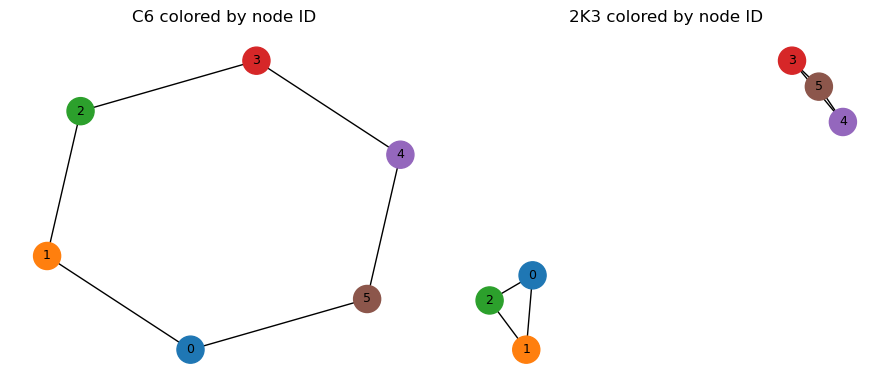


Random permutation applied to C6 node IDs: [3, 2, 5, 4, 0, 1]


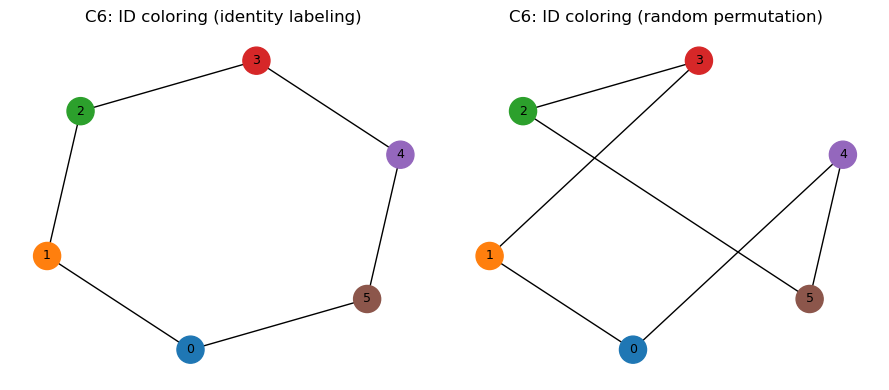

C6  (unique-ID init) color multisets per round:
  round 0: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
  round 1: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
  round 2: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
  round 3: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
2K3 (unique-ID init) color multisets per round:
  round 0: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
  round 1: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
  round 2: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
  round 3: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}


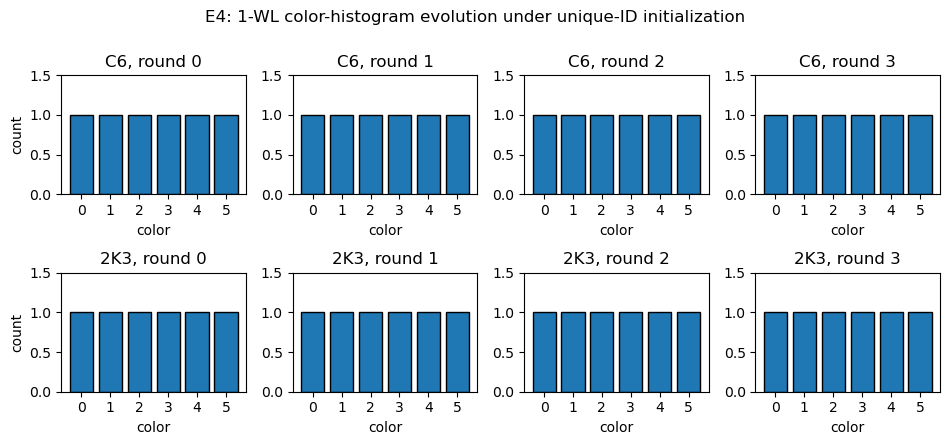

In [28]:
# E4: node identity / coloring as a "feature".
# Give every node a unique ID and use it as a label. With unique labels, 1-WL converges
# in one round and trivially distinguishes any two graphs of the same size.
# The catch: the feature DEPENDS on the labeling. Apply a permutation and the per-node
# feature vector changes, so this encoding is NOT permutation-equivariant — i.e. it lets
# the model see the labeling, not the graph.

def wl_one_round_with_ids(G):
    """Run a single 1-WL round starting from per-node unique IDs as initial colors."""
    init = {v: v for v in G.nodes()}
    return wl_refine(G, n_iter=1, init_labels=init)


# Show that IDs already separate C6 from 2K3
hist_c6_id  = wl_one_round_with_ids(graphs['C6'])
hist_2k3_id = wl_one_round_with_ids(graphs['2K3'])

print('C6 with ID init — colors after 1 round (sorted multiset of signatures):')
sig_c6 = sorted(Counter(hist_c6_id[1].values()).values())
sig_2k3 = sorted(Counter(hist_2k3_id[1].values()).values())
print(f'  C6  signature multiset = {sig_c6}')
print(f'  2K3 signature multiset = {sig_2k3}')
print(f'IDs trivially separate the two graphs (every node gets its own color): '
      f'{len(set(hist_c6_id[1].values())) == 6 and len(set(hist_2k3_id[1].values())) == 6}')

# Visualize the ID coloring side by side
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, name in zip(axes, ['C6', '2K3']):
    G = graphs[name]
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=0),
                     node_color=list(G.nodes()), cmap='tab10', vmin=0, vmax=9,
                     with_labels=True, node_size=380, font_size=9, ax=ax)
    ax.set_title(f'{name} colored by node ID')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Demonstrate non-equivariance: relabel C6 with a random permutation and re-color.
rng = np.random.default_rng(0)
n = graphs['C6'].number_of_nodes()
perm = rng.permutation(n)
print(f'\nRandom permutation applied to C6 node IDs: {perm.tolist()}')

G_perm = nx.relabel_nodes(graphs['C6'], {i: int(perm[i]) for i in range(n)})

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, G, title in [
    (axes[0], graphs['C6'], 'C6: ID coloring (identity labeling)'),
    (axes[1], G_perm,        'C6: ID coloring (random permutation)'),
]:
    nx.draw_networkx(G, pos=nx.spring_layout(graphs['C6'], seed=0),  # same physical layout
                     node_color=list(G.nodes()), cmap='tab10', vmin=0, vmax=9,
                     with_labels=True, node_size=380, font_size=9, ax=ax)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# E4 evolution: run 1-WL with unique-ID initial colors for 3 rounds on C6 and 2K3,
# and visualize the histogram evolution the same way as E1.
init_c6  = {v: v for v in graphs['C6'].nodes()}
init_2k3 = {v: v for v in graphs['2K3'].nodes()}

hist_c6_id_evo  = wl_refine(graphs['C6'],  n_iter=3, init_labels=init_c6)
hist_2k3_id_evo = wl_refine(graphs['2K3'], n_iter=3, init_labels=init_2k3)

print('C6  (unique-ID init) color multisets per round:')
for t, c in enumerate(histogram_evolution(hist_c6_id_evo)):
    print(f'  round {t}: {dict(c)}')
print('2K3 (unique-ID init) color multisets per round:')
for t, c in enumerate(histogram_evolution(hist_2k3_id_evo)):
    print(f'  round {t}: {dict(c)}')

plot_histogram_evolution(
    {'C6':  hist_c6_id_evo,
     '2K3': hist_2k3_id_evo},
    'E4: 1-WL color-histogram evolution under unique-ID initialization',
)


**What happens to the 1-WL histograms with unique IDs.**
Both $C_6$ and $2K_3$ have the histogram $\{1,1,1,1,1,1\}$ (six singletons) at every round, and the signature `(id, sorted neighbor ids)` of every node is unique within and across the two graphs.

**Why this trivially distinguishes the graphs.**
With $n$ distinct labels, the initial coloring is already a perfect classifier of node identity, and refinement just confirms that. No information about the graph structure is needed: even comparing graphs that are isomorphic, using different ID assignments produces different histograms. The distinguishing power comes from labels, not topology.

**Why this is not permutation-invariant or structurally meaningful.**
Node ID features are not permutation-invariant: the feature is the labeling, so under any relabeling the per-node feature changes to whatever $\pi$ assigns, and the multiset of `(id, neighborhood-of-ids)` signatures changes too. The same $C_6$ graph with a random permutation of node IDs receives a completely different per-node coloring, even though the graph is unchanged.


## Bonus: Oversquashing intuition on a barbell graph

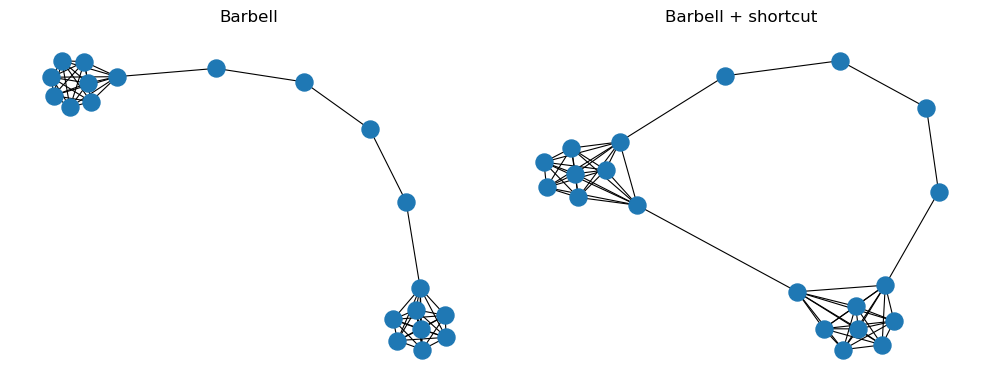

In [21]:
# Provided bonus graph visualization.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, G, title in zip(axes, [G_barbell, G_shortcut], ['Barbell', 'Barbell + shortcut']):
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=0), ax=ax,
                     node_size=150, with_labels=False, width=0.8)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [27]:
# Bonus 1: bottleneck statistics for G_barbell and G_shortcut.
# Report exactly the four spec-required quantities:
#   (1) Diameter
#   (2) Average shortest path length
#   (3) Spectral gap lambda_2 of the NORMALIZED Laplacian L_sym = I - D^{-1/2} A D^{-1/2}
#   (4) Maximum edge betweenness centrality and the edge attaining it.

def normalized_laplacian_lambda2(G):
    """lambda_2 of the normalized Laplacian L_sym = I - D^{-1/2} A D^{-1/2}.
    Eigenvalues are sorted ascending; lambda_2 is the second-smallest (since lambda_1 = 0)."""
    L_sym = nx.normalized_laplacian_matrix(G).toarray()
    eigvals = np.sort(np.linalg.eigvalsh(L_sym))
    return float(eigvals[1])

def max_edge_betweenness(G):
    """Return (edge, value) where edge maximizes edge-betweenness centrality."""
    eb = nx.edge_betweenness_centrality(G)
    edge, val = max(eb.items(), key=lambda kv: kv[1])
    return edge, float(val)

def bottleneck_stats(G, name):
    eb_edge, eb_val = max_edge_betweenness(G)
    return {
        'graph': name,
        'diameter': nx.diameter(G),
        'avg_shortest_path': nx.average_shortest_path_length(G),
        'lambda2_norm_laplacian': normalized_laplacian_lambda2(G),
        'max_edge_betweenness': eb_val,
        'argmax_edge': str(eb_edge),
    }

rows = [bottleneck_stats(G_barbell,  'barbell'),
        bottleneck_stats(G_shortcut, 'barbell + shortcut')]
display(pd.DataFrame(rows).set_index('graph'))


,diameter,avg_shortest_path,lambda2_norm_laplacian,max_edge_betweenness,argmax_edge
graph,,,,,
barbell,7,3.757895,0.006645,0.526316,"(9, 10)"
barbell + shortcut,4,2.326316,0.034808,0.421053,"(0, 19)"


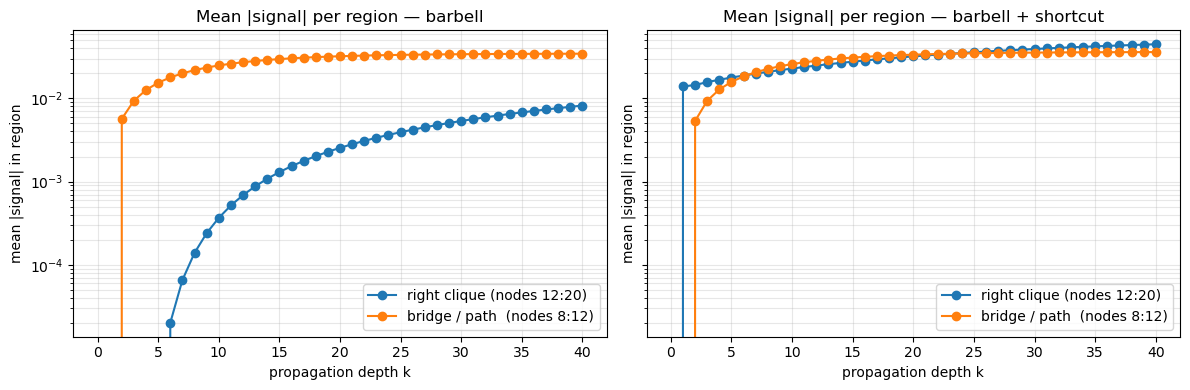

In [23]:
# Bonus 2: inject Dirac signal h0 = e_0 at node 0, propagate with the symmetric GCN matrix,
# and plot the mean absolute signal on the right clique and on the bridge/path nodes
# as a function of propagation depth k, for both graphs.

source_node = 0
m1, m2 = 8, 4                                      # barbell_graph(m1, m2)
bridge       = list(range(m1, m1 + m2))            # nodes 8:12  (path/bridge)
right_clique = list(range(m1 + m2, 2 * m1 + m2))   # nodes 12:20 (right clique)

# Symmetric GCN matrix S = D_hat^{-1/2} A_hat D_hat^{-1/2} for each graph.
S_barbell,  _ = symmetric_gcn_matrix_nx(G_barbell)
S_shortcut, _ = symmetric_gcn_matrix_nx(G_shortcut)

# h0 = e_0
n = G_barbell.number_of_nodes()
def dirac(n, source):
    x = np.zeros((n, 1))
    x[source, 0] = 1.0
    return x

K = 40
def propagate(S, x0, K):
    """Return (n, K+1) array whose columns are x_0, x_1, ..., x_K."""
    cols = [x0]
    x = x0.copy()
    for _ in range(K):
        x = S @ x
        cols.append(x)
    return np.hstack(cols)

signals_barbell  = propagate(S_barbell,  dirac(n, source_node), K)
signals_shortcut = propagate(S_shortcut, dirac(n, source_node), K)

def mean_abs(signals_mat, idx):
    """Mean absolute signal over a region's nodes, at each depth k."""
    return np.abs(signals_mat[idx, :]).mean(axis=0)

ks = np.arange(K + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, name, sig in [(axes[0], 'barbell',           signals_barbell),
                      (axes[1], 'barbell + shortcut', signals_shortcut)]:
    ax.plot(ks, mean_abs(sig, right_clique), marker='o',
            label='right clique (nodes 12:20)')
    ax.plot(ks, mean_abs(sig, bridge),       marker='o',
            label='bridge / path  (nodes 8:12)')
    ax.set_title(f'Mean |signal| per region — {name}')
    ax.set_xlabel('propagation depth k')
    ax.set_ylabel('mean |signal| in region')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend()

plt.tight_layout()
plt.show()


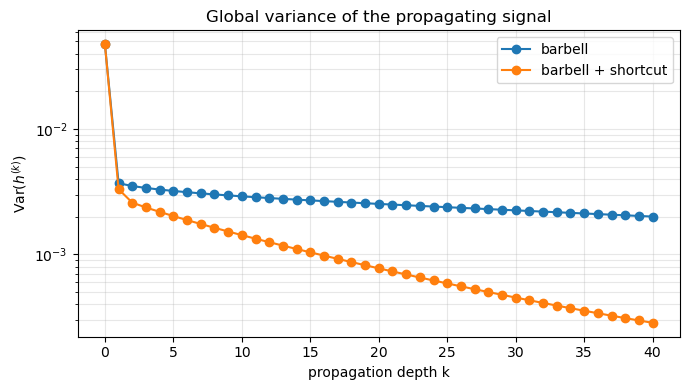

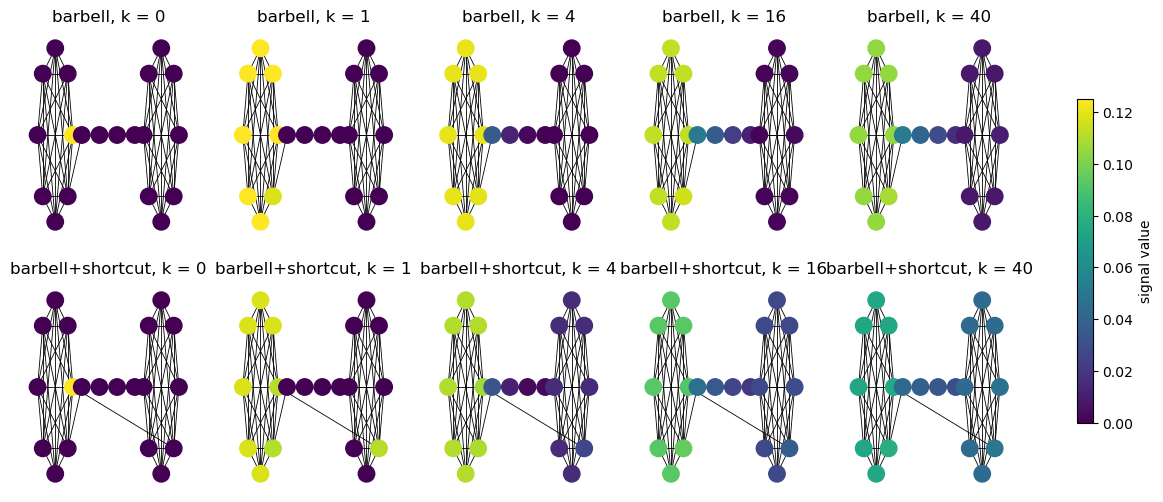

In [24]:
# Bonus 3: variance vs depth + signal snapshots at specific steps.
# Reuses signals_barbell and signals_shortcut from the cell above (K = 40).

# Global variance of h(k) at each depth.
var_barbell  = signals_barbell.var(axis=0)
var_shortcut = signals_shortcut.var(axis=0)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(ks, var_barbell,  marker='o', label='barbell')
ax.plot(ks, var_shortcut, marker='o', label='barbell + shortcut')
ax.set_yscale('log')
ax.set_xlabel('propagation depth k')
ax.set_ylabel(r'$\mathrm{Var}(h^{(k)})$')
ax.set_title('Global variance of the propagating signal')
ax.grid(True, alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.show()

# Snapshots at the spec-required steps with a shared color range across all panels.
snapshot_ks = [0, 1, 4, 16, 40]

# Shared color range across all panels.
# Compute it from the POST-INJECTION steps (k >= 1): the k=0 Dirac has value 1.0
# while every later step has values <= ~0.125, so including k=0 would squash all
# later panels into the bottom of the colormap and they'd look identical.
post = [k for k in snapshot_ks if k >= 1]
combined = np.concatenate([signals_barbell[:, post].ravel(),
                           signals_shortcut[:, post].ravel()])
vmin = float(combined.min())
vmax = float(combined.max())

# Layout: bridge horizontally between the two cliques.
def barbell_layout():
    pos = {}
    radius = 1.0
    for i, v in enumerate(range(0, m1)):
        theta = 2 * np.pi * i / m1
        pos[v] = (-3 + radius * np.cos(theta), radius * np.sin(theta))
    for i, v in enumerate(bridge):
        pos[v] = (-1.5 + 3.0 * i / max(m2 - 1, 1), 0.0)
    for i, v in enumerate(right_clique):
        theta = 2 * np.pi * i / m1
        pos[v] = (3 + radius * np.cos(theta), radius * np.sin(theta))
    return pos

pos_b = barbell_layout()

fig, axes = plt.subplots(2, len(snapshot_ks), figsize=(3.2 * len(snapshot_ks), 6))
for row, (name, G, sig) in enumerate([
    ('barbell',           G_barbell,  signals_barbell),
    ('barbell+shortcut',  G_shortcut, signals_shortcut),
]):
    for col, k in enumerate(snapshot_ks):
        ax = axes[row, col]
        nx.draw_networkx(
            G, pos=pos_b,
            node_color=sig[:, k], cmap='viridis', vmin=vmin, vmax=vmax,
            with_labels=False, node_size=140, width=0.6, ax=ax,
        )
        ax.set_title(f'{name}, k = {k}')
        ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, ax=axes, shrink=0.7, label='signal value')
plt.show()


### Bonus 3 — How the shortcut changes signal transfer and smoothing

In the barbell, every message from the left clique to the right must squeeze through a single bridge edge, so the right-clique mean-$|signal|$ curve in Bonus 2 climbs very slowly (this is **oversquashing**: information through a bottleneck is exponentially damped). The shortcut $(0,19)$ adds a second length-1 path between the cliques, so node 19 receives non-trivial mass already at $k=1$ and the right-clique curve climbs orders of magnitude faster. The same edge also lowers the second-largest eigenvalue of $S$ from $\approx 0.994$ to $\approx 0.970$, so the variance (which decays geometrically at twice that rate per step) plummets and the $k=16,40$ snapshots look uniform while the plain barbell still shows a left-vs-right gradient. In short, the shortcut **alleviates oversquashing** but **accelerates oversmoothing**: both effects come from the same source.
